Decision Tree

In [3]:
%pip install scikit-learn


   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.0 MB 5.6 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.0 MB 4.9 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.0 MB 4.9 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.0 MB 4.9 MB/s eta 0:00:02
   --------- ------------------------------ 2.1/9.0 MB 2.1 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/9.0 MB 2.1 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/9.0 MB 2.1 MB/s eta 0:00:04
   -------------- ------------------------- 3.1/9.0 MB 2.0 MB/s eta 0:00:03
   -------------- ------------------------- 3.1/9.0 MB 2.0 MB/s eta 0:00:03
   -------------- ------------------------- 3.1/9.0 MB 2.0 MB/s eta 0:00:03
   ------------------ --------------------- 4.2/9.0 MB 2.0 MB/s eta 0:00:03
   ------------------ --------------------- 4.2/9.0 MB 2.0 MB/s eta 0:00:03
   ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3.14t.exe -m pip install --upgrade pip


In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split




In [7]:
df = pd.read_csv("wbc.csv")

In [8]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
df.shape

(569, 32)

In [10]:
df.isnull().sum()


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [13]:
df.columns


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [14]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [15]:
#drop unrealatd column
df.drop(columns='id',inplace=True)

In [16]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [19]:
df['diagnosis'].unique()

<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

Define features and target 

In [21]:
x = df.loc[:,df.columns[1:]]
y = df['diagnosis']

# replace categorical value into numerical value 
# like M --> 1 and B--> 0
y = y.map({'M':1,'B':0})

In [22]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [26]:
#train the model
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=7)


2nd Task Jar:-superviser learning
    
3r MOdel Jar:- Binary tree structure
    to ask the right question the entropy-->measure

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [30]:
from sklearn.tree import DecisionTreeClassifier
#initialize the model
dt = DecisionTreeClassifier()
#fit the trainig data
dt.fit(x_train,y_train)
#predict on the test data
y_pred = dt.predict(x_test)
y_pred


array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

evaluate : find accuray of model

In [32]:
from sklearn.metrics import accuracy_score,f1_score
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print(acc)
print(f1)

0.9370629370629371
0.898876404494382


5th learning jar :-where we need find max depth using the hit and trail method

In [36]:
import numpy as np

In [49]:
from sklearn.model_selection import cross_val_score
for depth in[1,2,3,4,5,6,7,8,9,10,20,30]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(x_train,y_train)
    train_accuracy = dt.score(x_train,y_train)
    val_accuracy = cross_val_score(dt,x_train,y_train,cv=10)
    print('depth:',depth,'trainig accuracy:',train_accuracy,'cross_value_score:',np.mean(val_accuracy))

depth: 1 trainig accuracy: 0.9248826291079812 cross_value_score: 0.9061461794019934
depth: 2 trainig accuracy: 0.9483568075117371 cross_value_score: 0.9227021040974529
depth: 3 trainig accuracy: 0.9694835680751174 cross_value_score: 0.9223698781838318
depth: 4 trainig accuracy: 0.9859154929577465 cross_value_score: 0.9295127353266889
depth: 5 trainig accuracy: 0.9929577464788732 cross_value_score: 0.9317275747508307
depth: 6 trainig accuracy: 0.9953051643192489 cross_value_score: 0.9247508305647841
depth: 7 trainig accuracy: 1.0 cross_value_score: 0.9365448504983389
depth: 8 trainig accuracy: 1.0 cross_value_score: 0.9199335548172758
depth: 9 trainig accuracy: 1.0 cross_value_score: 0.9292912513842746
depth: 10 trainig accuracy: 1.0 cross_value_score: 0.9294019933554818
depth: 20 trainig accuracy: 1.0 cross_value_score: 0.9223698781838318
depth: 30 trainig accuracy: 1.0 cross_value_score: 0.9153377630121817


The bset maximum depth ill be getting 4

Again trainthe data

In [63]:
from sklearn.tree import DecisionTreeClassifier
#initialize the model
dt = DecisionTreeClassifier(max_depth=5)
#fit the trainig data
dt.fit(x_train,y_train)
#predict on the test data
y_pred = dt.predict(x_test)
y_pred


array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [64]:
from sklearn.metrics import accuracy_score,f1_score
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print(acc)
print(f1)

0.9440559440559441
0.9069767441860465


Feature importance

In [65]:
df.shape

(569, 31)

In [66]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=7)

In [69]:
from sklearn.tree import DecisionTreeClassifier
#initialize the model
dt =  DecisionTreeClassifier(criterion="gini",max_depth=5)
dt.fit(x_train,y_train)
importance = dt.feature_importances_
list(zip(importance,x_test.columns))

[(np.float64(0.0), 'radius_mean'),
 (np.float64(0.046359823061412425), 'texture_mean'),
 (np.float64(0.0), 'perimeter_mean'),
 (np.float64(0.0), 'area_mean'),
 (np.float64(0.0), 'smoothness_mean'),
 (np.float64(0.0), 'compactness_mean'),
 (np.float64(0.0), 'concavity_mean'),
 (np.float64(0.08995656708773318), 'concave points_mean'),
 (np.float64(0.0), 'symmetry_mean'),
 (np.float64(0.0013190035744923404), 'fractal_dimension_mean'),
 (np.float64(0.0), 'radius_se'),
 (np.float64(0.0), 'texture_se'),
 (np.float64(0.0), 'perimeter_se'),
 (np.float64(0.003166099807228499), 'area_se'),
 (np.float64(0.0), 'smoothness_se'),
 (np.float64(0.0), 'compactness_se'),
 (np.float64(0.016550226313446638), 'concavity_se'),
 (np.float64(0.028580409270930533), 'concave points_se'),
 (np.float64(0.0), 'symmetry_se'),
 (np.float64(0.0), 'fractal_dimension_se'),
 (np.float64(0.0), 'radius_worst'),
 (np.float64(0.0), 'texture_worst'),
 (np.float64(0.7360816016865359), 'perimeter_worst'),
 (np.float64(0.007599

[Text(0.555, 0.9166666666666666, 'perimeter_worst <= 106.1\ngini = 0.477\nsamples = 426\nvalue = [259, 167]\nclass = y[0]'),
 Text(0.37, 0.75, 'symmetry_worst <= 0.362\ngini = 0.078\nsamples = 247\nvalue = [237, 10]\nclass = y[0]'),
 Text(0.4625, 0.8333333333333333, 'True  '),
 Text(0.26, 0.5833333333333334, 'smoothness_worst <= 0.191\ngini = 0.033\nsamples = 239\nvalue = [235.0, 4.0]\nclass = y[0]'),
 Text(0.16, 0.4166666666666667, 'area_se <= 47.035\ngini = 0.025\nsamples = 237\nvalue = [234, 3]\nclass = y[0]'),
 Text(0.08, 0.25, 'fractal_dimension_mean <= 0.054\ngini = 0.017\nsamples = 234\nvalue = [232, 2]\nclass = y[0]'),
 Text(0.04, 0.08333333333333333, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]\nclass = y[0]'),
 Text(0.12, 0.08333333333333333, 'gini = 0.009\nsamples = 227\nvalue = [226, 1]\nclass = y[0]'),
 Text(0.24, 0.25, 'concavity_se <= 0.056\ngini = 0.444\nsamples = 3\nvalue = [2, 1]\nclass = y[0]'),
 Text(0.2, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\n

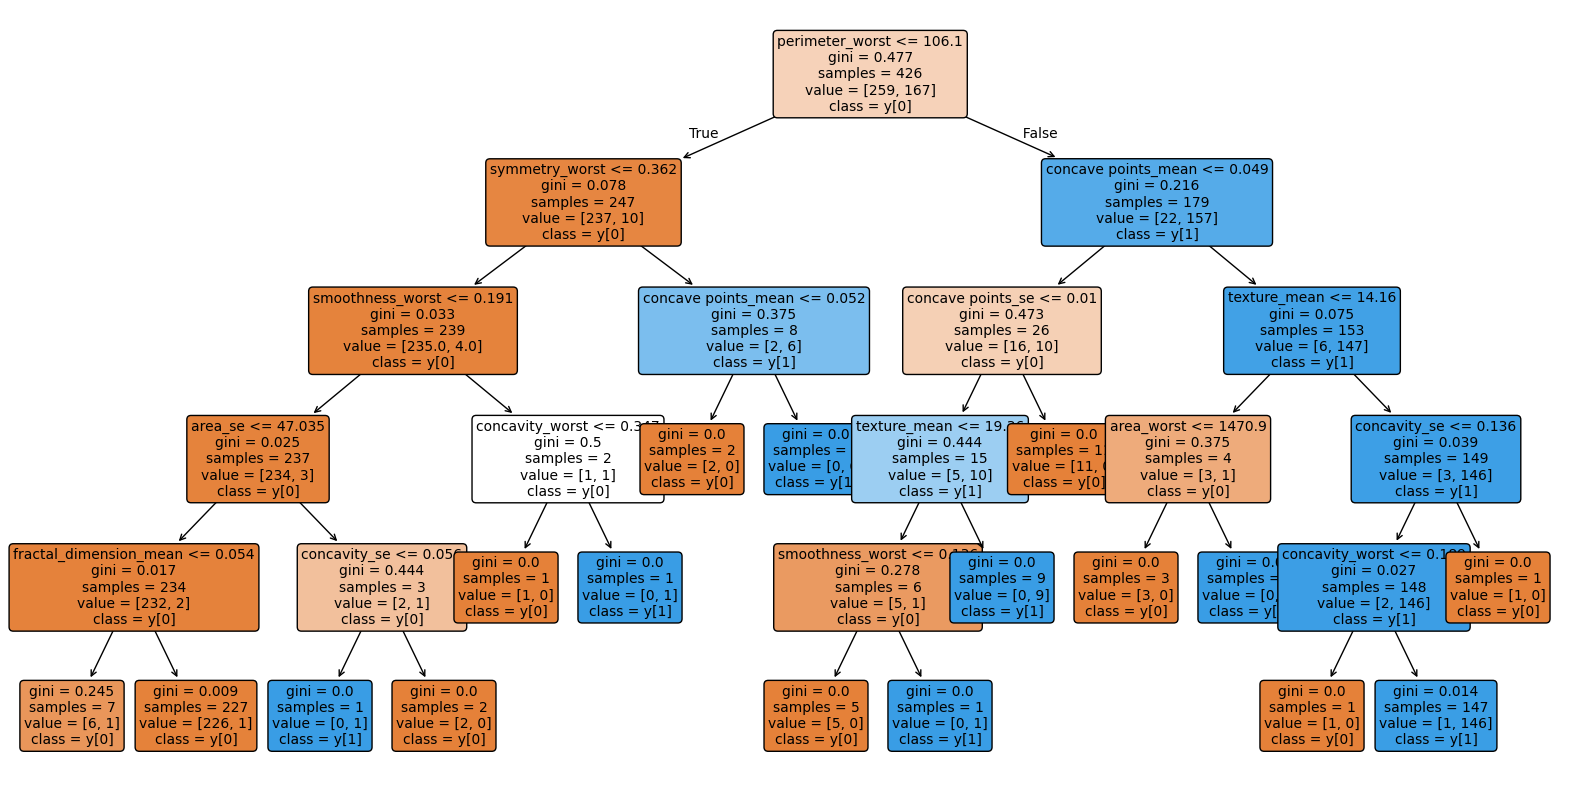

In [71]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
tree.plot_tree(dt,filled=True,rounded=True,feature_names=x_train.columns,class_names=True,fontsize=10)

Logistic REgressiioin

In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)



In [74]:
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression()
logistic_regression.fit(x_train,y_train)
y_pred = logistic_regression.predict(x_test)
y_pred

C:\Users\amanm\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1])

In [78]:
from sklearn.metrics import accuracy_score,f1_score
accuracy_score(y_pred,y_test)
f1_score(y_pred,y_test)
#print(acc)
#print(f1score)

0.9272727272727272

In [79]:
import numpy as np

In [80]:
from sklearn.model_selection import cross_val_score
for depth in[1,2,3,4,5,6,7,8,9,10,20,30]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(x_train,y_train)
    train_accuracy = dt.score(x_train,y_train)
    val_accuracy = cross_val_score(dt,x_train,y_train,cv=10)
    print('depth:',depth,'trainig accuracy:',train_accuracy,'cross_value_score:',np.mean(val_accuracy))

depth: 1 trainig accuracy: 0.9225352112676056 cross_value_score: 0.8780177187153931
depth: 2 trainig accuracy: 0.9413145539906104 cross_value_score: 0.9085271317829458
depth: 3 trainig accuracy: 0.9765258215962441 cross_value_score: 0.936655592469546
depth: 4 trainig accuracy: 0.9929577464788732 cross_value_score: 0.9413067552602437
depth: 5 trainig accuracy: 0.9929577464788732 cross_value_score: 0.9342746400885936
depth: 6 trainig accuracy: 0.9976525821596244 cross_value_score: 0.9249169435215947
depth: 7 trainig accuracy: 0.9976525821596244 cross_value_score: 0.9179955703211518
depth: 8 trainig accuracy: 1.0 cross_value_score: 0.9272425249169436
depth: 9 trainig accuracy: 1.0 cross_value_score: 0.9272978959025471
depth: 10 trainig accuracy: 1.0 cross_value_score: 0.9203211517165005
depth: 20 trainig accuracy: 1.0 cross_value_score: 0.9202104097452934
depth: 30 trainig accuracy: 1.0 cross_value_score: 0.9203765227021041
